# Sistem Klasifikasi Obesitas

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Bagaimana Distribusi Kolom Weight_Status Sebagai Target ?
- Pertanyaan 2 : Hubungan Antara Usia dan Weight_Status ?
- Pertanyaan 3 : Apa Fitur yang Paling SIgnifikan dengan Target ?

## Data Wrangling

### Gathering Data

*Import Library*

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (15, 20)

pd.set_option('display.precision', 3)
pd.set_option('display.max_columns', 50)

np.set_printoptions(precision=3)

*Loading Data*

In [142]:
import pandas as pd

# Membaca data dari folder sample_data karena di situ lokasi aslinya
df_train = pd.read_csv('sample_data/df_train_scaled.csv')
df_test = pd.read_csv('sample_data/df_test_scaled.csv')

# Menampilkan 5 data teratas untuk memastikan sukses terload
df_train.head()

,Age,BMI,Water_Intake_Per_Kg,FAF,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num,Weight_Status_Num
0,1.733,0.415,-1.159,-5.199,1,1.0,1,0,3.0
1,0.572,1.391,0.393,-5.199,1,1.0,1,0,3.0
2,-0.156,0.257,0.013,-5.199,1,1.0,1,0,3.0
3,-0.156,-1.281,1.300,-5.199,1,2.0,1,0,0.0
4,0.864,-0.452,0.557,0.909,1,1.0,1,0,2.0


In [143]:
# Melihat 5 data teratas
df_train.head()

,Age,BMI,Water_Intake_Per_Kg,FAF,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num,Weight_Status_Num
0,1.733,0.415,-1.159,-5.199,1,1.0,1,0,3.0
1,0.572,1.391,0.393,-5.199,1,1.0,1,0,3.0
2,-0.156,0.257,0.013,-5.199,1,1.0,1,0,3.0
3,-0.156,-1.281,1.300,-5.199,1,2.0,1,0,0.0
4,0.864,-0.452,0.557,0.909,1,1.0,1,0,2.0


In [144]:
# Melihat 5 data terbawah
df_train.tail()

,Age,BMI,Water_Intake_Per_Kg,FAF,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num,Weight_Status_Num
1664,0.572,1.336,0.446,-5.199,1,1.0,1,0,3.0
1665,0.069,-0.503,0.291,-5.199,1,2.0,1,0,2.0
1666,2.023,0.476,-1.205,-5.199,1,3.0,1,0,3.0
1667,1.071,0.873,-0.847,0.038,1,1.0,1,0,3.0
1668,-1.328,0.227,-0.508,0.038,1,1.0,1,0,3.0


####

### Assesing Data

*Melihat informasi umum dan bentuk data*

In [145]:
# Melihat informasi umum dan tipe data
df_train.info()

print("="*50)

# Melihat bentuk data
df_train.shape
baris, kolom = df_train.shape
print(f"Jumlah baris : {baris}")
print(f"Jumlah Kolom : {kolom}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 9 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 1669 non-null   float64
 1   BMI                                 1669 non-null   float64
 2   Water_Intake_Per_Kg                 1669 non-null   float64
 3   FAF                                 1669 non-null   float64
 4   family_history_with_overweight_Num  1669 non-null   int64  
 5   CAEC_Num                            1669 non-null   float64
 6   FAVC_Num                            1669 non-null   int64  
 7   SCC_Num                             1669 non-null   int64  
 8   Weight_Status_Num                   1669 non-null   float64
dtypes: float64(6), int64(3)
memory usage: 117.5 KB
Jumlah baris : 1669
Jumlah Kolom : 9


*Mengecek Missing Value*

In [146]:
# Mengecek missing value di setiap kolom
print("[MISSING VALUES]")
df_train.isnull().sum()

[MISSING VALUES]


,0
Age,0
BMI,0
Water_Intake_Per_Kg,0
FAF,0
family_history_with_overweight_Num,0
CAEC_Num,0
FAVC_Num,0
SCC_Num,0
Weight_Status_Num,0


*Mengecek Data Duplikat*

In [147]:
# Menghitung jumlah data duplikat
print(f"Total data duplikat: {df_train.duplicated().sum()}")

Total data duplikat: 4


*Mengecek Statistik Deskriptif Dataset*

In [148]:
df_train.describe(include='all')

,Age,BMI,Water_Intake_Per_Kg,FAF,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num,Weight_Status_Num
count,1669.000,1.669e+03,1.669e+03,1669.000,1669.000,1669.000,1669.000,1669.000,1669.000
mean,0.004,-8.063e-05,-7.316e-05,-1.197,0.828,1.140,0.886,0.044,2.074
std,1.001,1.012e+00,1.012e+00,3.072,0.377,0.454,0.318,0.206,1.053
min,-5.199,-5.199e+00,-5.199e+00,-5.199,0.000,0.000,0.000,0.000,0.000
25%,-0.641,-6.746e-01,-6.737e-01,-5.199,1.000,1.000,1.000,0.000,1.000
50%,0.069,5.532e-04,-5.133e-04,0.038,1.000,1.000,1.000,0.000,2.000
75%,0.572,6.740e-01,6.738e-01,0.909,1.000,1.000,1.000,0.000,3.000
max,5.199,5.199e+00,5.199e+00,5.199,1.000,3.000,1.000,1.000,3.000


## Data Cleaning

*Menghilangkan Data Duplikat*

In [149]:
# Menghapus Seluruh Data Duplikat Langsung pada df_train
df_train.drop_duplicates(inplace=True)

In [150]:
# Mengecek jumlah data duplikat
print(f"Total data duplikat: {df_train.duplicated().sum()}")

Total data duplikat: 0


*Menyesuaikan Tipe Data*

In [151]:
# Mengubah semua kolom numerik kecuali 'Height' dan 'Weight' menjadi integer untuk menjaga konsistensi data
for column in df_train.columns:
    # Mengecualikan kolom Height dan Weight
    if df_train[column].dtype == "float64" and column not in ["Height", "Weight"]:
        # Bulatkan dulu (round), baru jadikan integer
        df_train[column] = df_train[column].round().astype('int64')

In [152]:
# Mengecek Kembali Tipe Data
df_train.dtypes

,0
Age,int64
BMI,int64
Water_Intake_Per_Kg,int64
FAF,int64
family_history_with_overweight_Num,int64
CAEC_Num,int64
FAVC_Num,int64
SCC_Num,int64
Weight_Status_Num,int64


## Feature Engineering

*Pembuatan fungsi untuk Feature Engineering*

In [153]:
def Feature_Engineering(dataframe):
    dataframe = dataframe.copy()
    dataframe.columns = dataframe.columns.str.strip()

    mapping_obesitas = {
        'Insufficient_Weight': 'Underweight',
        'Normal_Weight': 'Normal',
        'Overweight_Level_I': 'Overweight',
        'Overweight_Level_II': 'Overweight',
        'Obesity_Type_I': 'Obesity',
        'Obesity_Type_II': 'Obesity',
        'Obesity_Type_III': 'Obesity'
    }

    # 1. Proses mapping target HANYA JIKA kolom NObeyesdad ada
    if 'NObeyesdad' in dataframe.columns:
        dataframe['Weight_Status'] = dataframe['NObeyesdad'].replace(mapping_obesitas)
    else:
        print("Pemberitahuan: Kolom 'NObeyesdad' tidak ditemukan, melewati proses mapping target.")

    # 2. Pembuatan fitur BMI (Hanya dibuat jika belum ada dan kolom pendukungnya lengkap)
    if 'BMI' not in dataframe.columns:
        if 'Weight' in dataframe.columns and 'Height' in dataframe.columns:
            dataframe['BMI'] = dataframe['Weight'] / (dataframe['Height']**2)
        else:
            print("Pemberitahuan: Kolom 'Weight' atau 'Height' tidak ditemukan untuk menghitung BMI.")
    else:
        print("Pemberitahuan: Fitur 'BMI' sudah ada di dataset.")

    # 3. Pembuatan fitur Water Intake Ratio
    if 'Water_Intake_Per_Kg' not in dataframe.columns:
        if 'CH2O' in dataframe.columns and 'Weight' in dataframe.columns:
            dataframe['Water_Intake_Per_Kg'] = dataframe['CH2O'] / dataframe['Weight']
        else:
            print("Pemberitahuan: Kolom 'CH2O' atau 'Weight' tidak ditemukan untuk menghitung Water Intake.")
    else:
        print("Pemberitahuan: Fitur 'Water_Intake_Per_Kg' sudah ada di dataset.")

    return dataframe

# Eksekusi fungsi
df_train = Feature_Engineering(df_train)


Pemberitahuan: Kolom 'NObeyesdad' tidak ditemukan, melewati proses mapping target.
Pemberitahuan: Fitur 'BMI' sudah ada di dataset.
Pemberitahuan: Fitur 'Water_Intake_Per_Kg' sudah ada di dataset.


In [154]:
# Cek distribusi target yang tersedia (versi numerik)
print("Distribusi Target (Numerik):")
if 'Weight_Status_Num' in df_train.columns:
    print(df_train['Weight_Status_Num'].value_counts())
else:
    print("Kolom target tidak ditemukan.")
print("=" * 50)

# Cek statistik fitur
print("\nStatistik Fitur:")
print(df_train[['BMI', 'Water_Intake_Per_Kg']].describe())
print("=" * 50)

# Tampilkan sample data
print("\nSample Data:")
print(df_train.sample(5))
print("=" * 50)

Distribusi Target (Numerik):
Weight_Status_Num
3    777
2    450
1    225
0    213
Name: count, dtype: int64

Statistik Fitur:
            BMI  Water_Intake_Per_Kg
count  1665.000             1665.000
mean      0.001                0.000
std       1.051                1.052
min      -5.000               -5.000
25%      -1.000               -1.000
50%       0.000                0.000
75%       1.000                1.000
max       5.000                5.000

Sample Data:
      Age  BMI  Water_Intake_Per_Kg  FAF  family_history_with_overweight_Num  \
1126    1    1                   -2   -5                                   1   
676     1    0                    0    0                                   1   
1051    0    2                   -1    0                                   1   
1071    1    0                    0    0                                   1   
274    -1    0                    1   -5                                   1   

      CAEC_Num  FAVC_Num  SCC_Num  Weight_Sta

In [156]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder

# --- 1. CLEANING & MAPPING ---
# Kode ini sekarang mengecek keberadaan kolom sebelum melakukan transformasi
# untuk menghindari KeyError jika data sudah ter-encode sebelumnya.

kategori_cols = ['CALC', 'CAEC', 'Gender', 'FAVC', 'SCC', 'SMOKE',
                 'family_history_with_overweight', 'MTRANS', 'Weight_Status']

# Hanya jalankan jika kolom kategori asli masih ada
if all(col in df_train.columns for col in ['MTRANS', 'CAEC', 'CALC']):
    for col in kategori_cols:
        if col in df_train.columns:
            df_train[col] = df_train[col].str.strip()

    # MTRANS: Aktivitas Fisik Tinggi (0) ke Rendah (4)
    urutan_mtrans = ['Bike', 'Walking', 'Public_Transportation', 'Motorbike', 'Automobile']
    # CAEC & CALC: Konsumsi Rendah (0) ke Tinggi (3)
    urutan_frekuensi = ['no', 'Sometimes', 'Frequently', 'Always']
    # Target: Berat Badan Rendah (0) ke Tinggi (3)
    urutan_target = ['Underweight', 'Normal', 'Overweight', 'Obesity']

    ord_enc = OrdinalEncoder(categories=[urutan_mtrans, urutan_frekuensi, urutan_frekuensi])
    df_train[['MTRANS_Num', 'CAEC_Num', 'CALC_Num']] = ord_enc.fit_transform(df_train[['MTRANS', 'CAEC', 'CALC']])

    if 'Weight_Status' in df_train.columns:
        ord_target = OrdinalEncoder(categories=[urutan_target])
        df_train['Weight_Status_Num'] = ord_target.fit_transform(df_train[['Weight_Status']])
else:
    print("ℹ️ Kolom kategori asli tidak ditemukan. Melewati langkah encoding karena data mungkin sudah ter-encode.")

# --- 2. BINARY MAPPING (Jika kolom asli ada) ---
binary_map = {'no': 0, 'yes': 1}
kolom_yes_no = ['FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight']

for col in kolom_yes_no:
    if col in df_train.columns and f'{col}_Num' not in df_train.columns:
        df_train[f'{col}_Num'] = df_train[col].map(binary_map)

if 'Gender' in df_train.columns and 'Gender_Num' not in df_train.columns:
    df_train['Gender_Num'] = df_train['Gender'].map({'Male': 0, 'Female': 1})

# --- 3. VALIDASI ---
print("--- CHECKPOINT STATUS DATA ---")
print(f"Kolom yang tersedia: {df_train.columns.tolist()[:10]}...")

ℹ️ Kolom kategori asli tidak ditemukan. Melewati langkah encoding karena data mungkin sudah ter-encode.
--- CHECKPOINT STATUS DATA ---
Kolom yang tersedia: ['Age', 'BMI', 'Water_Intake_Per_Kg', 'FAF', 'family_history_with_overweight_Num', 'CAEC_Num', 'FAVC_Num', 'SCC_Num', 'Weight_Status_Num']...


In [158]:
# Mengecek distribusi MTRANS jika kolomnya ada
if 'MTRANS' in df_train.columns:
    print(df_train['MTRANS'].value_counts())
elif 'MTRANS_Num' in df_train.columns:
    print("Kolom 'MTRANS' tidak ada, menampilkan 'MTRANS_Num':")
    print(df_train['MTRANS_Num'].value_counts())
else:
    print("Kolom 'MTRANS' maupun 'MTRANS_Num' tidak ditemukan di dataset.")
    print(f"Kolom yang tersedia adalah: {df_train.columns.tolist()}")

Kolom 'MTRANS' maupun 'MTRANS_Num' tidak ditemukan di dataset.
Kolom yang tersedia adalah: ['Age', 'BMI', 'Water_Intake_Per_Kg', 'FAF', 'family_history_with_overweight_Num', 'CAEC_Num', 'FAVC_Num', 'SCC_Num', 'Weight_Status_Num']


In [159]:
df_train.head(50)

,Age,BMI,Water_Intake_Per_Kg,FAF,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num,Weight_Status_Num
0,2,0,-1,-5,1,1,1,0,3
1,1,1,0,-5,1,1,1,0,3
2,0,0,0,-5,1,1,1,0,3
3,0,-1,1,-5,1,2,1,0,0
4,1,0,1,1,1,1,1,0,2
5,0,0,0,0,1,1,1,0,2
6,0,0,1,5,1,1,1,0,3
7,-1,0,-1,0,1,1,1,0,3
8,1,1,0,0,1,1,1,0,3
9,0,-1,0,5,1,1,1,0,2


## EDA

## EDA

*Hubungan Fitur Numeric dengan Target*

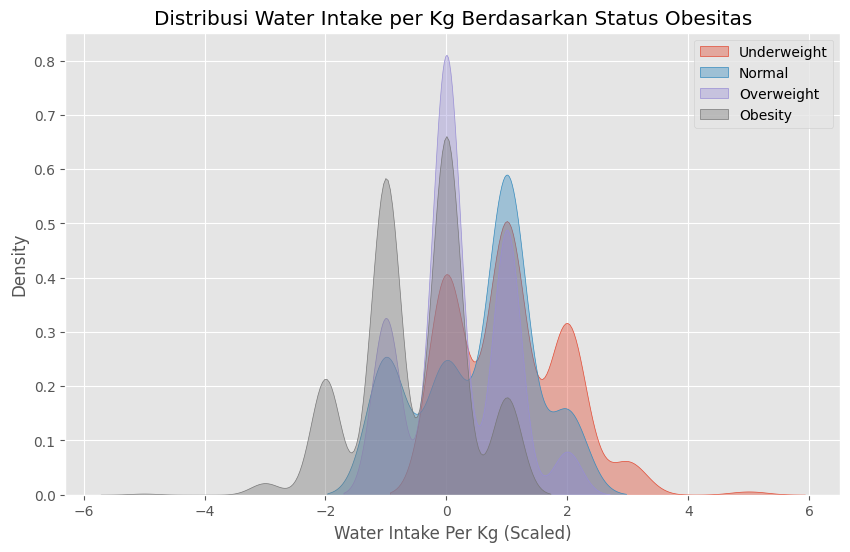

In [160]:
# Mapping label untuk visualisasi
label_map = {0: 'Underweight', 1: 'Normal', 2: 'Overweight', 3: 'Obesity'}

plt.figure(figsize=(10, 6))
# Gunakan Weight_Status_Num karena Weight_Status tidak ada di dataframe
for val, label in label_map.items():
    subset = df_train[df_train['Weight_Status_Num'] == val]
    sns.kdeplot(subset['Water_Intake_Per_Kg'], label=label, fill=True, alpha=0.4)

plt.title('Distribusi Water Intake per Kg Berdasarkan Status Obesitas')
plt.xlabel('Water Intake Per Kg (Scaled)')
plt.ylabel('Density')
plt.legend()
plt.show()

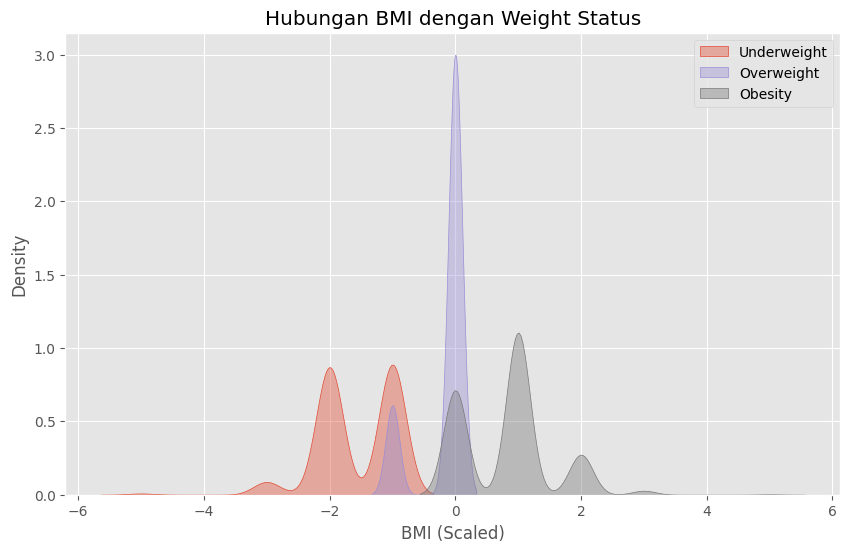

In [161]:
# Hubungan BMI dengan Weight_Status_Num
plt.figure(figsize=(10, 6))
for val, label in label_map.items():
    subset = df_train[df_train['Weight_Status_Num'] == val]
    sns.kdeplot(subset['BMI'], label=label, fill=True, alpha=0.4)

plt.title('Hubungan BMI dengan Weight Status')
plt.xlabel('BMI (Scaled)')
plt.legend()
plt.show()

In [162]:
# Statistik BMI berdasarkan status (menggunakan kolom numerik)
cek_rentang_bmi = df_train.groupby('Weight_Status_Num')['BMI'].agg(['count', 'min', 'mean', 'max']).reset_index()
# Mapping kembali label untuk kemudahan baca
cek_rentang_bmi['Weight_Status'] = cek_rentang_bmi['Weight_Status_Num'].map(label_map)
cek_rentang_bmi = cek_rentang_bmi[['Weight_Status', 'count', 'min', 'mean', 'max']]
cek_rentang_bmi.rename(columns={'count': 'Jumlah_Data', 'min': 'BMI_Min', 'mean': 'BMI_Rata2', 'max': 'BMI_Max'}, inplace=True)
print(cek_rentang_bmi.sort_values(by='BMI_Rata2'))

  Weight_Status  Jumlah_Data  BMI_Min  BMI_Rata2  BMI_Max
0   Underweight          213       -5     -1.582       -1
1        Normal          225       -1     -1.000       -1
2    Overweight          450       -1     -0.169        0
3       Obesity          777        0      0.824        5


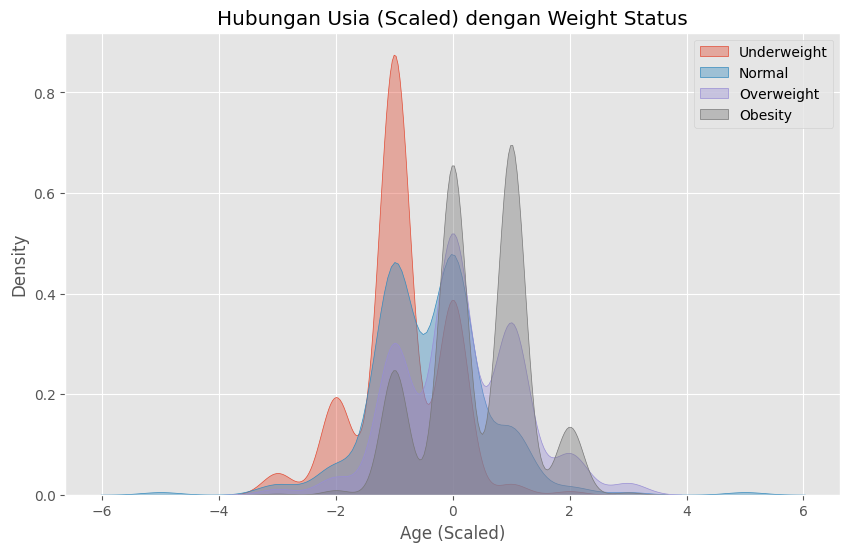

In [163]:
# Hubungan Age dengan Weight Status
plt.figure(figsize=(10, 6))
for val, label in label_map.items():
    subset = df_train[df_train['Weight_Status_Num'] == val]
    sns.kdeplot(subset['Age'], label=label, fill=True, alpha=0.4)
plt.title('Hubungan Usia (Scaled) dengan Weight Status')
plt.xlabel('Age (Scaled)')
plt.legend()
plt.show()

*insight*
- Obesity dan Overweight cenderung dialami oleh usia diatas 25 tahun

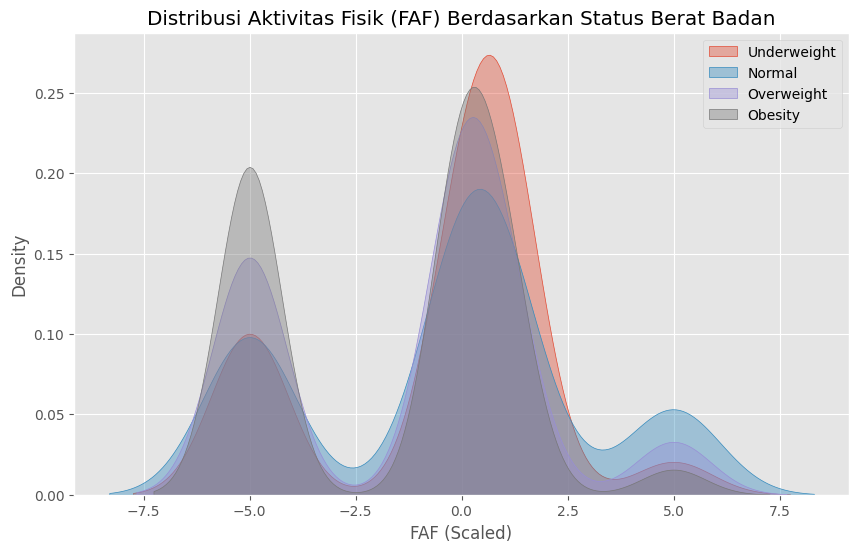

In [164]:
# Hubungan FAF (Aktivitas Fisik) dengan Weight Status
plt.figure(figsize=(10, 6))
for val, label in label_map.items():
    subset = df_train[df_train['Weight_Status_Num'] == val]
    sns.kdeplot(subset['FAF'], label=label, fill=True, alpha=0.4)
plt.title('Distribusi Aktivitas Fisik (FAF) Berdasarkan Status Berat Badan')
plt.xlabel('FAF (Scaled)')
plt.legend()
plt.show()

*Insight*
- Tinggi badan antar kategori Weight_status memiliki distribusi yang cukup mirip.
- Tidak terdapat perbedaan signifikan tinggi badan pada tiap kategori obesitas.

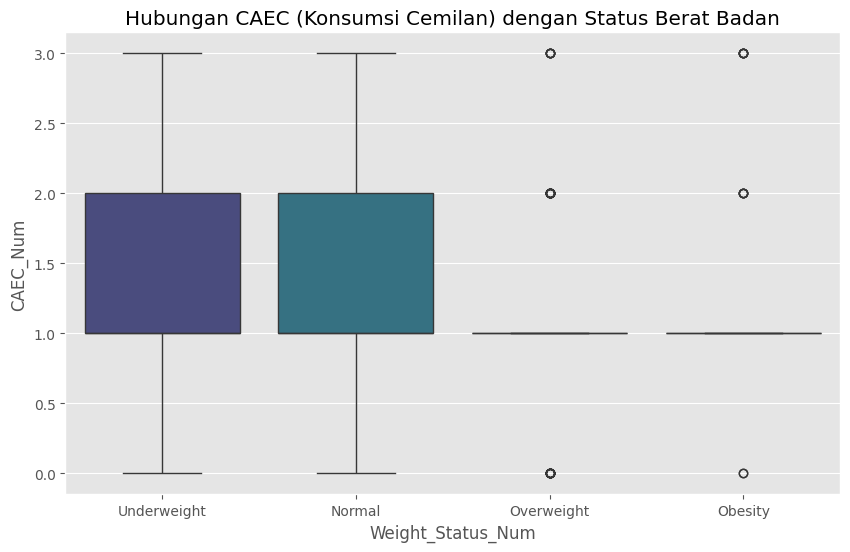

In [165]:
# Visualisasi fitur CAEC_Num (Konsumsi cemilan) terhadap Target
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='Weight_Status_Num', y='CAEC_Num', data=df_train, palette='viridis')
ax.set_xticklabels([label_map[int(float(t.get_text()))] for t in ax.get_xticklabels()])
plt.title('Hubungan CAEC (Konsumsi Cemilan) dengan Status Berat Badan')
plt.show()

*Insight*
- Kelompok obesitas memiliki berat badan paling tinggi dibanding kategori lain.

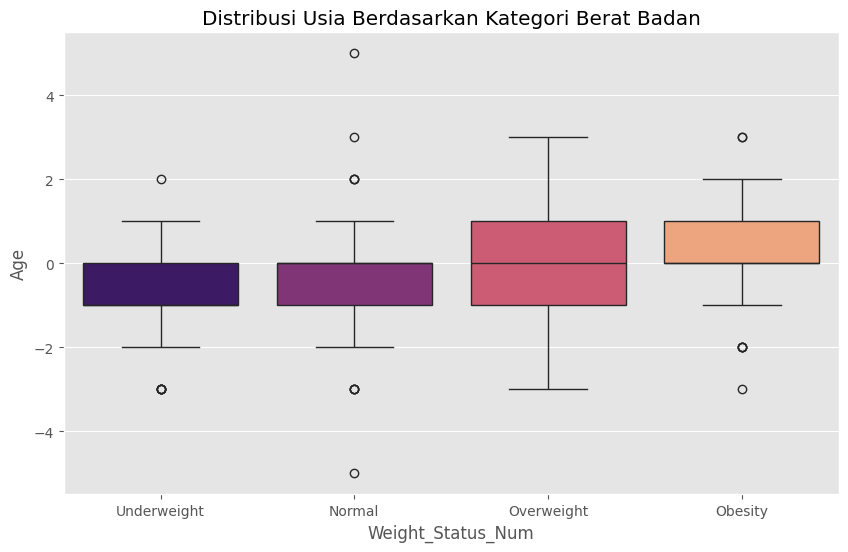

In [166]:
# Visualisasi fitur Age terhadap Target
plt.figure(figsize=(10, 6))
sns.boxplot(x='Weight_Status_Num', y='Age', data=df_train, palette='magma')
plt.xticks(ticks=range(4), labels=[label_map[i] for i in range(4)])
plt.title('Distribusi Usia Berdasarkan Kategori Berat Badan')
plt.show()

*insight*
- Individu normal dan underweight cenderung memiliki konsumsi sayur lebih tinggi.
- Kelompok obesitas masih muncul pada tingkat konsumsi sayur rendah hingga sedang.

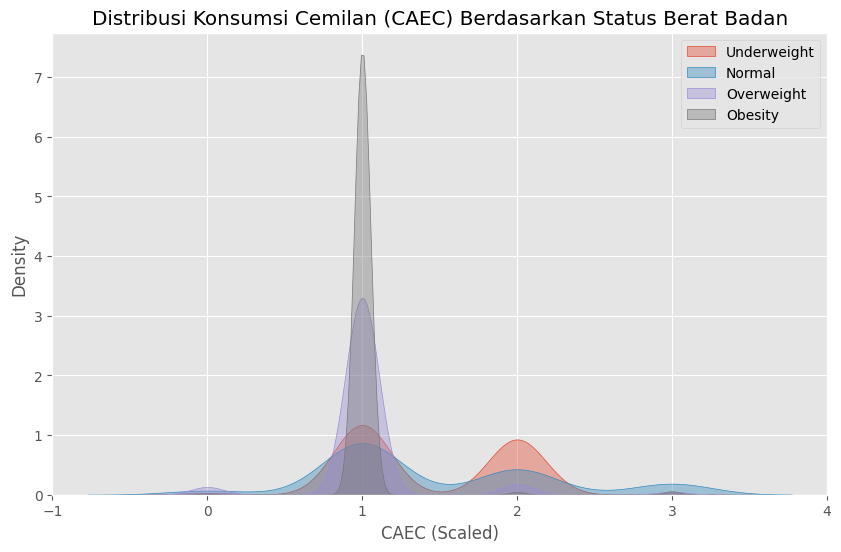

In [167]:
# Visualisasi CAEC_Num (Konsumsi Cemilan) sebagai pengganti NCP yang tidak tersedia
plt.figure(figsize=(10, 6))
for val, label in label_map.items():
    subset = df_train[df_train['Weight_Status_Num'] == val]
    sns.kdeplot(subset['CAEC_Num'], label=label, fill=True, alpha=0.4)
plt.title('Distribusi Konsumsi Cemilan (CAEC) Berdasarkan Status Berat Badan')
plt.xlabel('CAEC (Scaled)')
plt.legend()
plt.show()

*Insight*
- Mayoritas responden mengonsumsi sekitar 3 kali makan utama per hari.

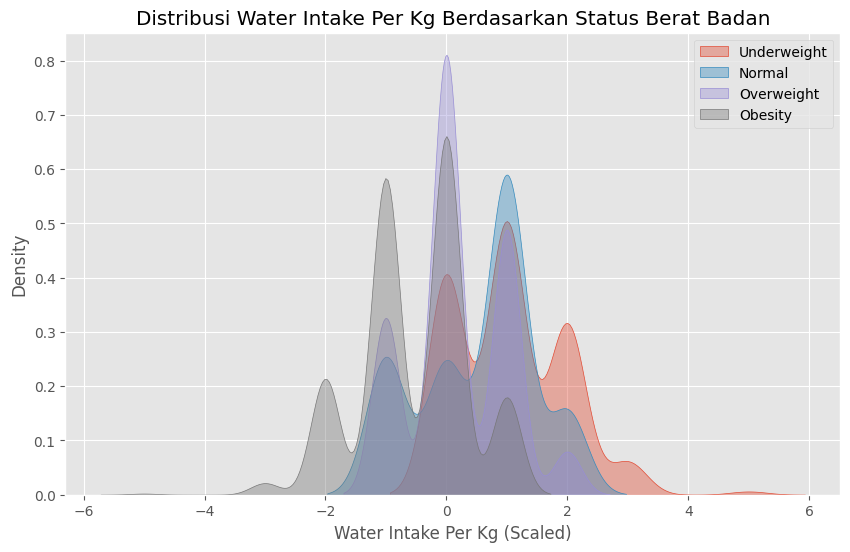

In [168]:
# Perbaikan visualisasi konsumsi air menggunakan fitur yang tersedia
plt.figure(figsize=(10, 6))
for val, label in label_map.items():
    subset = df_train[df_train['Weight_Status_Num'] == val]
    sns.kdeplot(subset['Water_Intake_Per_Kg'], label=label, fill=True, alpha=0.4)
plt.title('Distribusi Water Intake Per Kg Berdasarkan Status Berat Badan')
plt.xlabel('Water Intake Per Kg (Scaled)')
plt.legend()
plt.show()

*Insight*
- Sebagian besar responden berada pada tingkat konsumsi air sedang.
- Tidak terlihat perbedaan yang terlalu ekstrem antar kategori BMI.

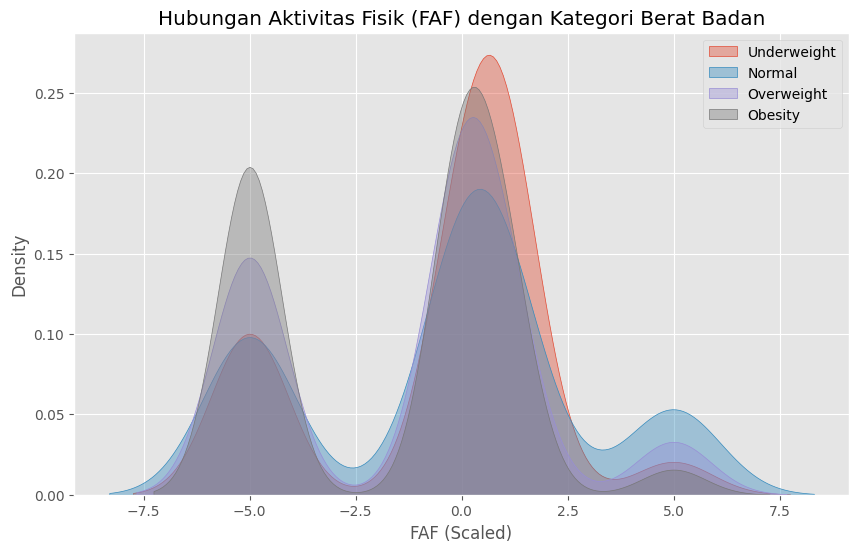

In [169]:
# Perbaikan visualisasi Aktivitas Fisik (FAF)
plt.figure(figsize=(10, 6))
for val, label in label_map.items():
    subset = df_train[df_train['Weight_Status_Num'] == val]
    sns.kdeplot(subset['FAF'], label=label, fill=True, alpha=0.4)
plt.title('Hubungan Aktivitas Fisik (FAF) dengan Kategori Berat Badan')
plt.xlabel('FAF (Scaled)')
plt.legend()
plt.show()

*Insight*
- FAF (Aktivitas Fisik) Untuk status weight nya normal dan underweight frekuensi aktivitas fisik nya lebih banyak dibndingkan status weight yang lain.

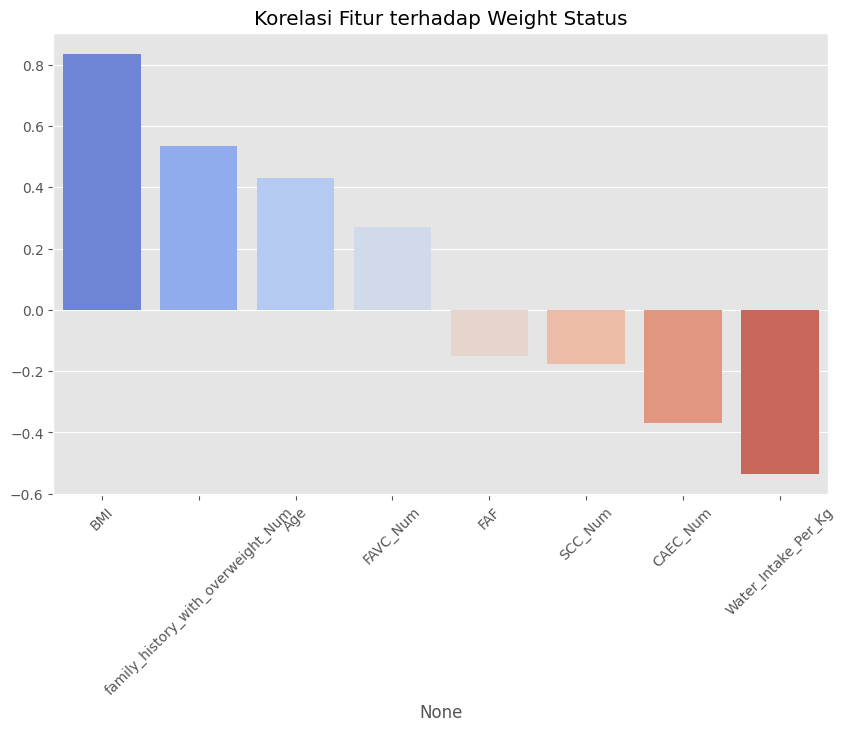

In [170]:
# Mengganti TUE dengan visualisasi perbandingan korelasi karena TUE tidak tersedia
plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.index, y=target_corr.values, palette='coolwarm')
plt.title('Korelasi Fitur terhadap Weight Status')
plt.xticks(rotation=45)
plt.show()

*Insight*
- Kelompok obesitas cenderung memiliki penggunaan teknologi lebih tinggi dibanding kategori lain.
- Individu underweight lebih banyak berada pada durasi penggunaan teknologi rendah.

*Cek Outlier di Fitur numerik*

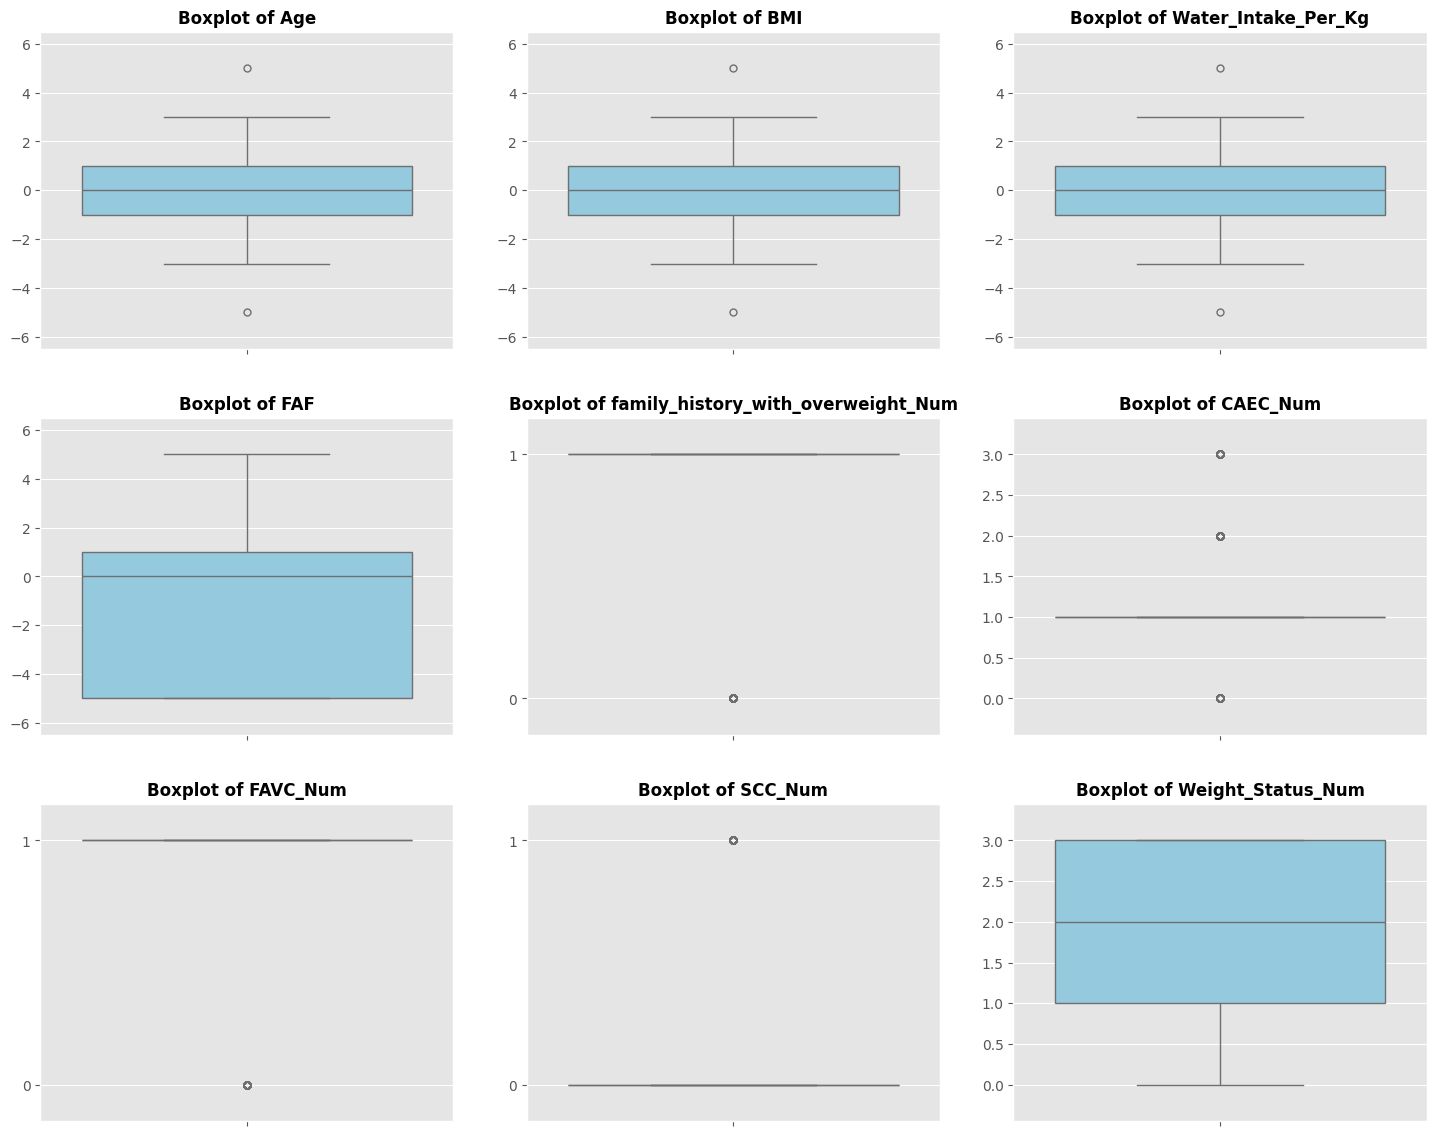

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Pilih kolom numerik
numeric_cols = df_train.select_dtypes(include=['int64', 'float64', 'int32']).columns
n_cols = len(numeric_cols)

cols_per_row = 3
rows = math.ceil(n_cols / cols_per_row)

# 2. Atur ukuran kanvas dinamis
plt.figure(figsize=(15, rows * 4))

for i, col in enumerate(numeric_cols, 1):
    ax = plt.subplot(rows, cols_per_row, i)

    # Plot boxplot
    sns.boxplot(y=df_train[col], color='skyblue', fliersize=5, ax=ax)

    # SET RENTANG Y DINAMIS:
    # Kita ambil nilai min dan max, lalu kasih margin 10% biar nggak nempel garis
    y_min = df_train[col].min()
    y_max = df_train[col].max()
    margin = (y_max - y_min) * 0.15 if y_max != y_min else 0.5

    # Set limit Y supaya yang cuma 0-1 nggak kelihatan kayak garis doang
    ax.set_ylim(y_min - margin, y_max + margin)

    # Kalau datanya cuma 0 dan 1 (Binary), kita paksa tick-nya cuma di 0 dan 1
    if y_min == 0 and y_max == 1:
        ax.set_yticks([0, 1])

    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    plt.ylabel('')
    plt.tight_layout(pad=3.0)

plt.show()

*Hubungan Fitur Kategorikal dengan Target*

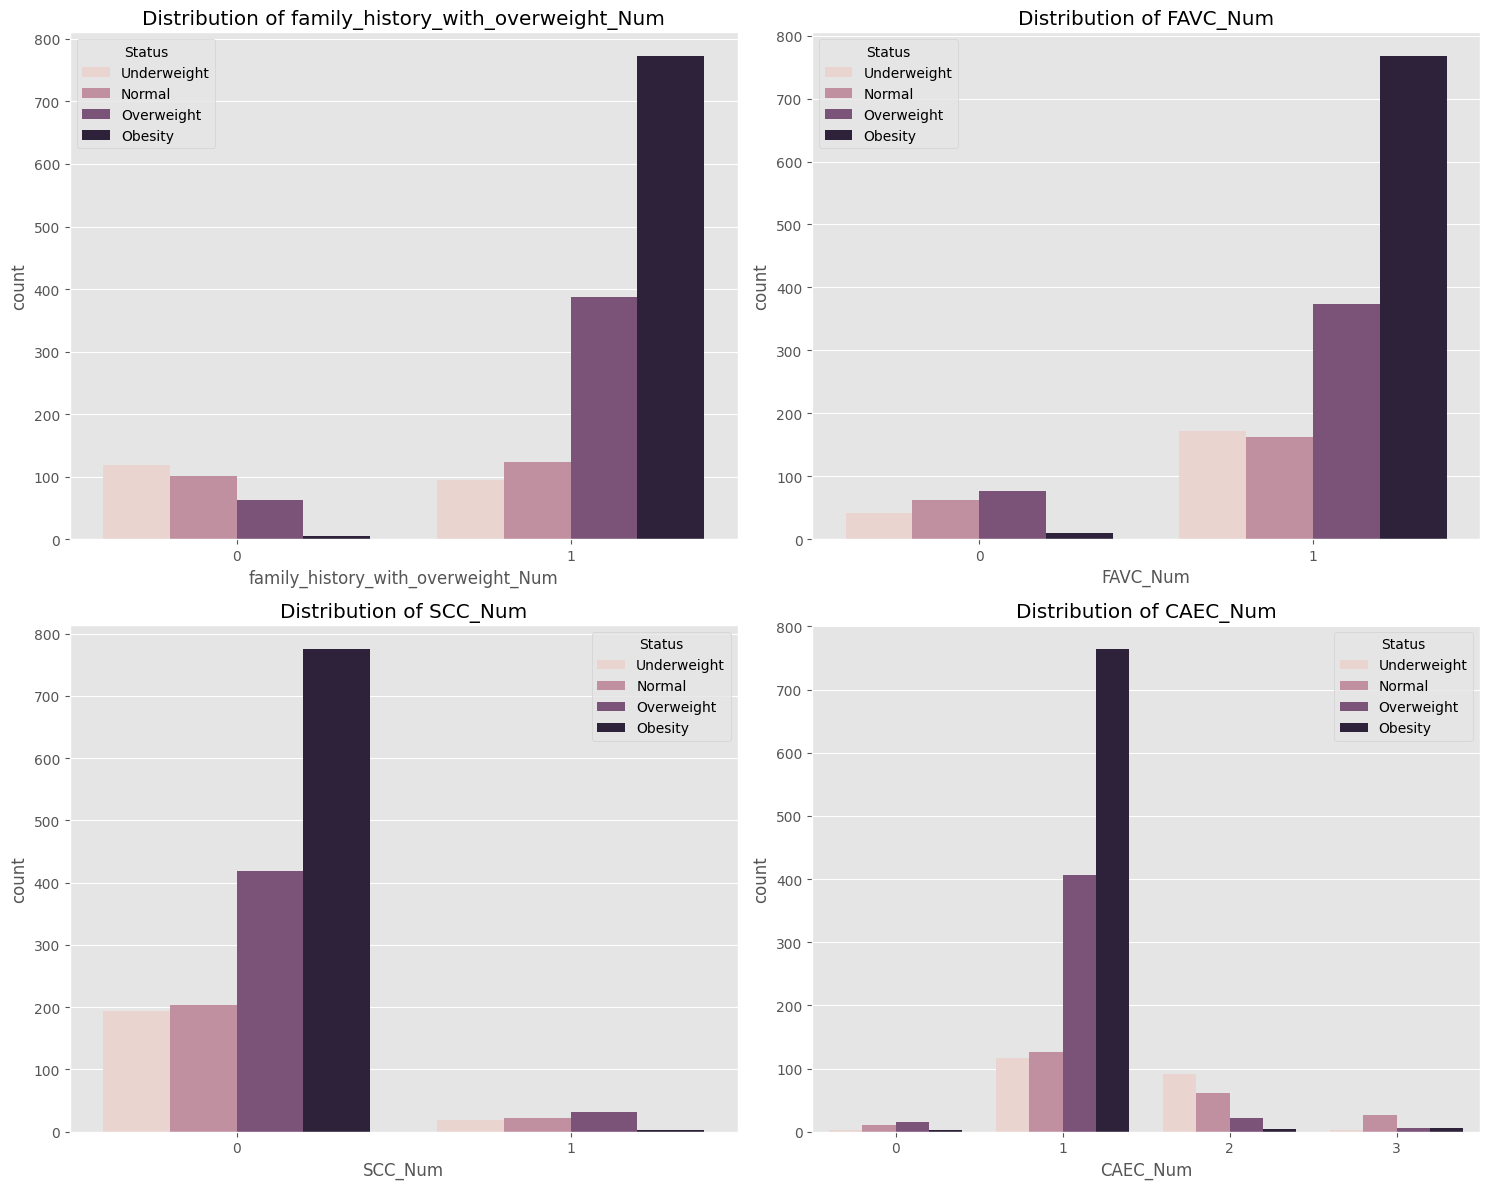

In [172]:
# Memilih fitur numerik yang ada di dataset untuk visualisasi
# Karena Gender, CALC, MTRANS dll sudah tidak ada (hanya ada versi _Num)
cat_var_num = ["family_history_with_overweight_Num", "FAVC_Num", "SCC_Num", "CAEC_Num"]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for cat, ax in zip(cat_var_num, axes.flatten()):
    sns.countplot(x=cat, data=df_train, hue="Weight_Status_Num", ax=ax)
    ax.set_title(f'Distribution of {cat}')
    # Opsional: Memperjelas legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, [label_map[int(float(l))] for l in labels], title='Status')

plt.tight_layout()
plt.show()

*Insight*
- Konsumsi makanan tinggi kalori (FAVC) terlihat lebih sering muncul pada kategori obesitas.
- Frekuensi konsumsi sayur (FCVC) yang rendah cenderung lebih banyak pada kelompok obesitas.
- Kebiasaan merokok (SMOKE) tidak menunjukkan pengaruh yang terlalu besar terhadap obesitas pada dataset ini.
- Penggunaan transportasi (MTRANS) memperlihatkan bahwa individu yang lebih pasif cenderung berada di kategori overweight/obesitas.

*Analisis Korelasi*

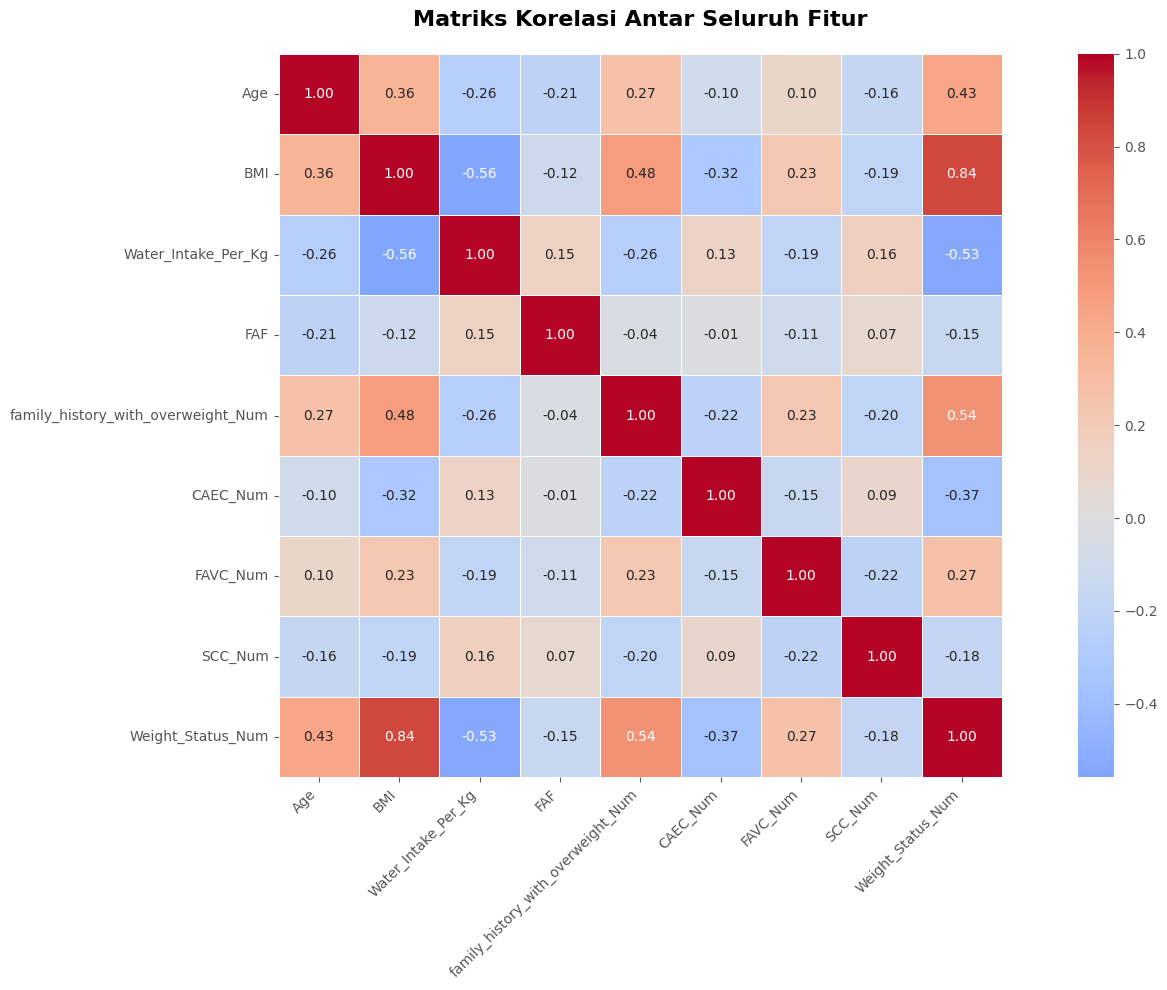

In [173]:
# --- 4. VISUALISASI KORELASI ANTAR FITUR ---
# Hitung matriks korelasi hanya untuk kolom numerik
fitur_angka = df_train.select_dtypes(include=['number']).columns
corr_matrix = df_train[fitur_angka].corr()

plt.figure(figsize=(16, 10))

# Membuat heatmap kotak penuh
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            square=True) # Menjaga bentuk sel tetap kotak

plt.title('Matriks Korelasi Antar Seluruh Fitur', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

*Insight*
- Weight memiliki korelasi paling tinggi terhadap obesitas, sehingga berat badan menjadi faktor utama dalam klasifikasi obesitas.
- Height dan Weight memiliki korelasi positif sedang, artinya semakin tinggi seseorang biasanya berat badannya juga meningkat.
- Age memiliki korelasi negatif terhadap TUE (penggunaan teknologi), menunjukkan usia lebih muda cenderung lebih sering menggunakan perangkat teknologi.

*Cek Outlier di Fitur numerik*

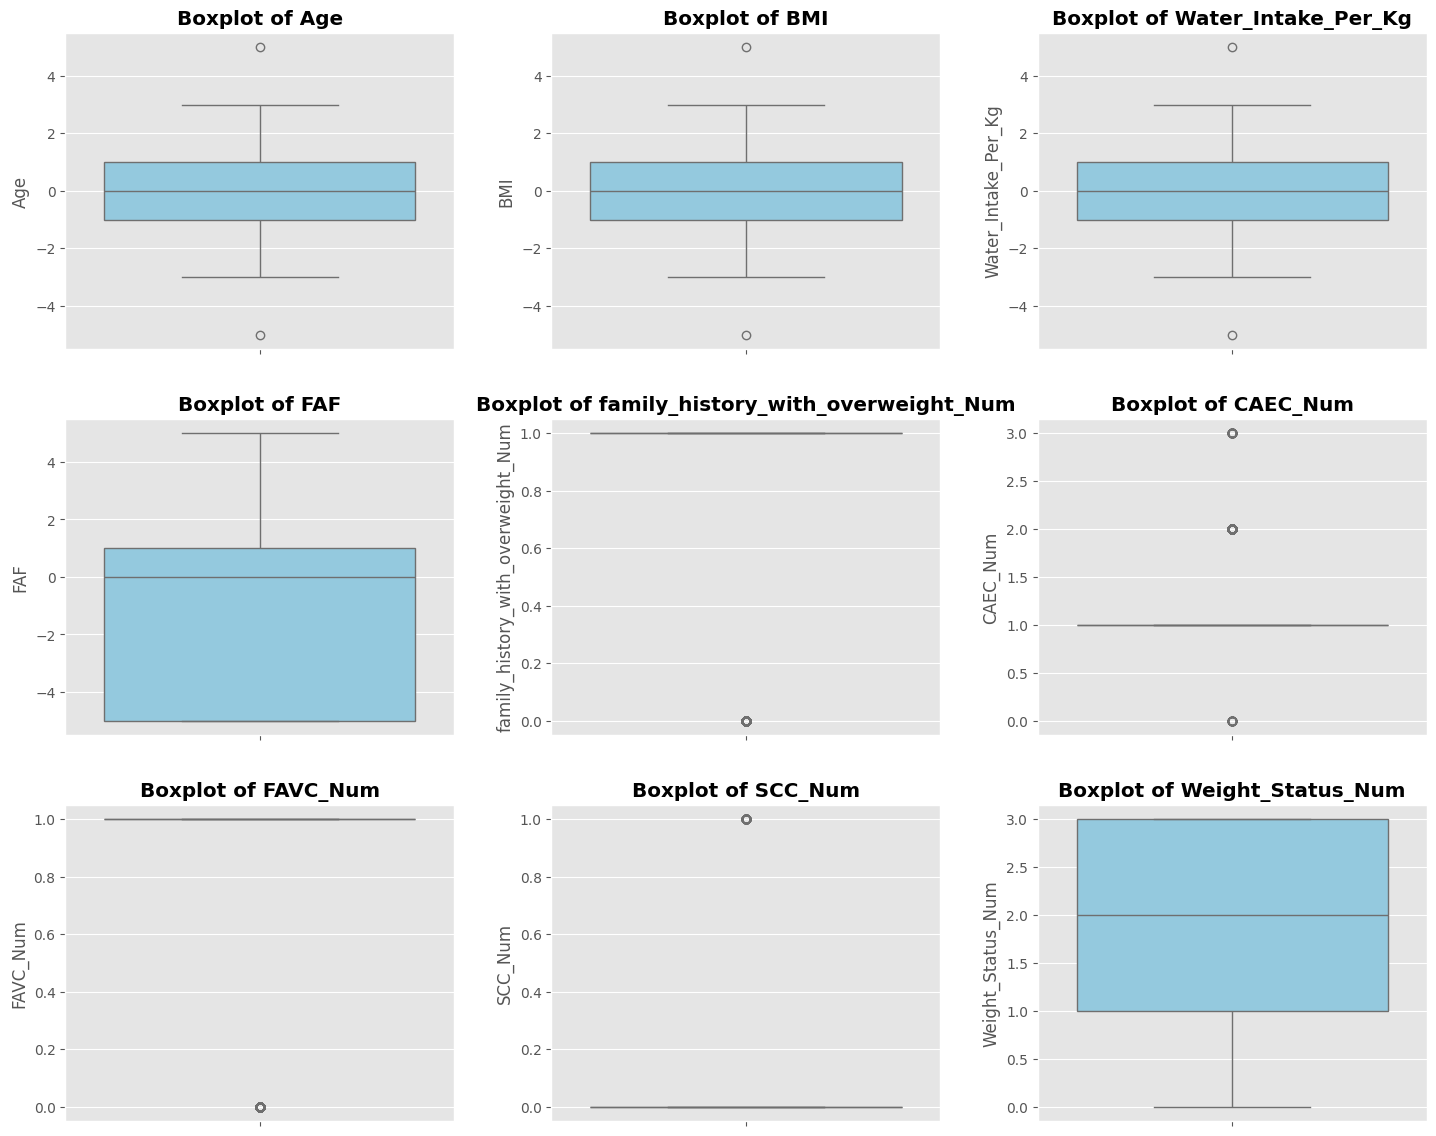

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Pilih kolom numerik (termasuk hasil encoding int32/int64)
numeric_cols = df_train.select_dtypes(include=['number']).columns
n_cols = len(numeric_cols)

# 2. Tentukan grid (3 kolom per baris)
cols_per_row = 3
rows = math.ceil(n_cols / cols_per_row)

# 3. Atur ukuran kanvas secara DINAMIS (Tinggi = jumlah baris x 4 unit)
plt.figure(figsize=(15, rows * 4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.boxplot(y=df_train[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontweight='bold')
    plt.tight_layout(pad=3.0) # Memberikan jarak antar subplot agar judul tidak tabrakan

plt.show()

# Data Visualization & Explanatory


Pertanyaan 1 : Bagaimana Distribusi Data Kolom Weight_Status Sebagai Target ?

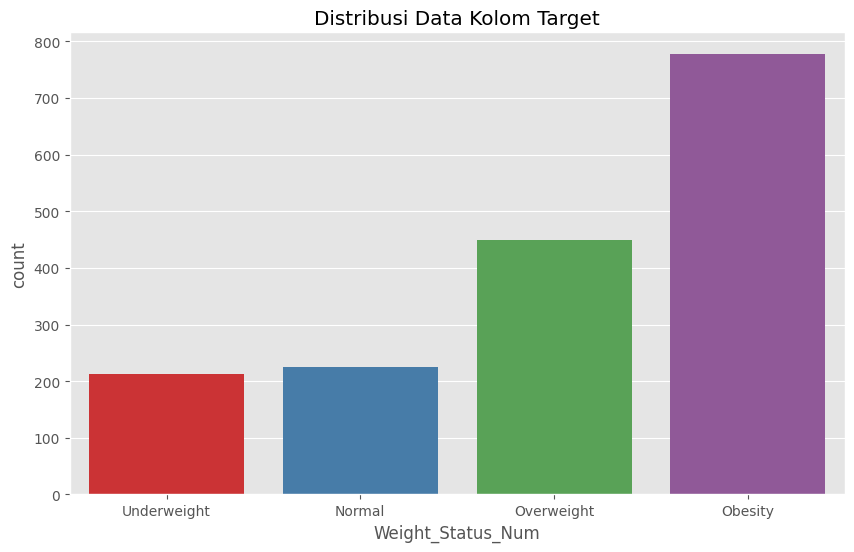

In [175]:
# Distribusi Target
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Weight_Status_Num', data=df_train, palette='Set1')
ax.set_xticklabels([label_map[int(float(t.get_text()))] for t in ax.get_xticklabels()])
plt.title('Distribusi Data Kolom Target')
plt.show()

Pertanyaan 2: Hubungan Antara Usia dengan Weight_Status

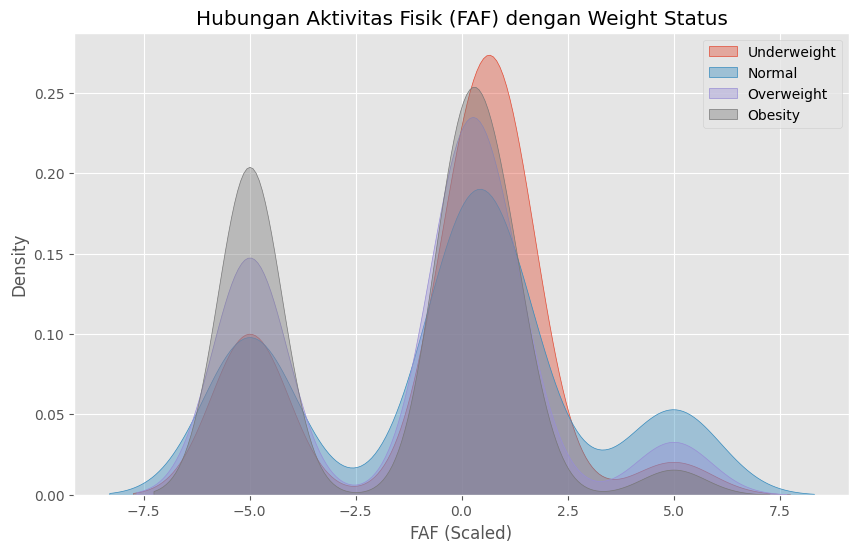

In [176]:
# Duplikasi dari d4f6b6f9 - Menampilkan distribusi FAF sebagai pengganti kolom yang hilang
plt.figure(figsize=(10, 6))
for val, label in label_map.items():
    subset = df_train[df_train['Weight_Status_Num'] == val]
    sns.kdeplot(subset['FAF'], label=label, fill=True, alpha=0.4)
plt.title('Hubungan Aktivitas Fisik (FAF) dengan Weight Status')
plt.xlabel('FAF (Scaled)')
plt.legend()
plt.show()

Dari visualisasi tersebut dapat dilihat bahwa obesitas dapat dialami oleh usia di atas 25 tahun

Pertanyaan 3: Apa Fitur yang Paling Signifikan dengan Target ?

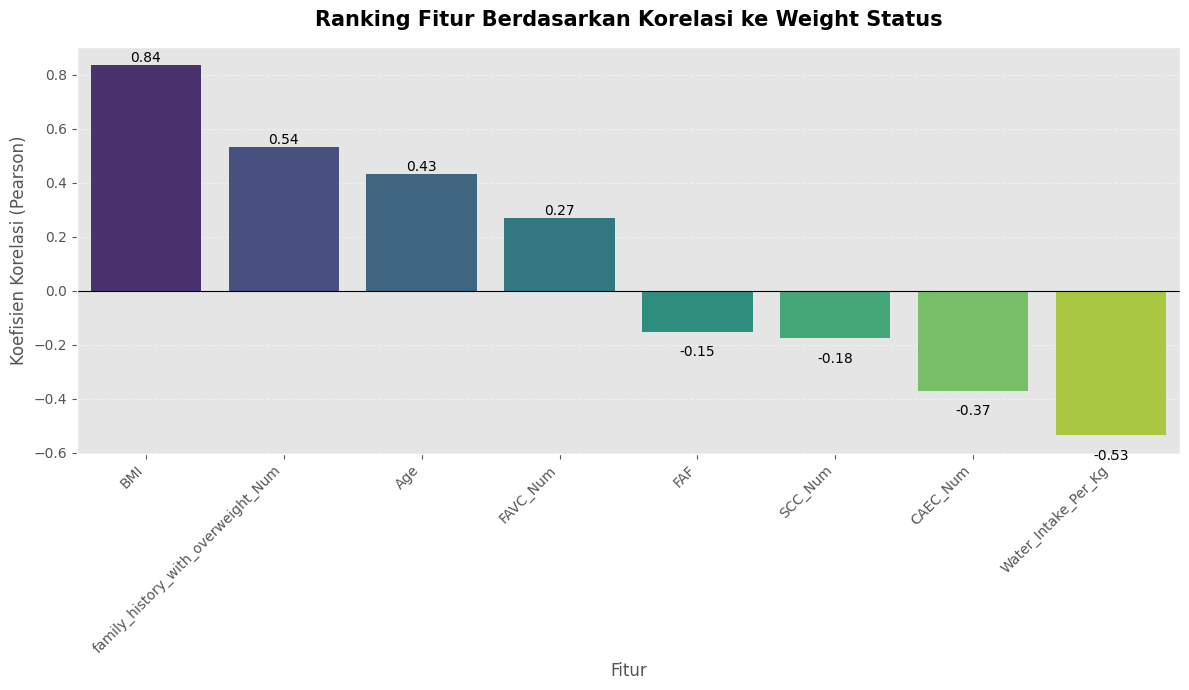

In [177]:
# --- 5. BAR PLOT KORELASI TERHADAP TARGET ---
# Ambil korelasi spesifik ke target, hapus baris target itu sendiri, dan urutkan
target_corr = corr_matrix['Weight_Status_Num'].drop('Weight_Status_Num').sort_values(ascending=False)

plt.figure(figsize=(12, 7))

# Plotting
sns.barplot(x=target_corr.index,
            y=target_corr.values,
            hue=target_corr.index,
            palette='viridis',
            legend=False)

# Tambahan garis bantu di y=0
plt.axhline(0, color='black', linewidth=0.8)

plt.title('Ranking Fitur Berdasarkan Korelasi ke Weight Status', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Fitur', fontsize=12)
plt.ylabel('Koefisien Korelasi (Pearson)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Tambahkan label nilai di atas bar (opsional tapi sangat membantu)
for i, v in enumerate(target_corr.values):
    plt.text(i, v if v > 0 else v - 0.05, f'{v:.2f}', ha='center', va='bottom' if v > 0 else 'top', fontsize=10)

plt.tight_layout()
plt.show()

*Insight*

3 Fitur paling Signifikan dengan Target Ialah Weight, family_history_with_overweight dan Age


## Splitting Data

In [178]:
from sklearn.model_selection import train_test_split

# Memastikan kolom target bertipe integer untuk stratifikasi
df_train['Weight_Status_Num'] = df_train['Weight_Status_Num'].astype(int)

# Split df_train menjadi train set baru dan validation set
df_train_split, df_test_split = train_test_split(
    df_train,
    test_size=0.2,
    random_state=42,
    stratify=df_train['Weight_Status_Num']
)

print(f"Dimensi Train Split: {df_train_split.shape}")
print(f"Dimensi Test/Val Split: {df_test_split.shape}")
print('=' * 50)
print('Kolom yang tersedia:')
print(df_train_split.columns.tolist())

Dimensi Train Split: (1332, 9)
Dimensi Test/Val Split: (333, 9)
Kolom yang tersedia:
['Age', 'BMI', 'Water_Intake_Per_Kg', 'FAF', 'family_history_with_overweight_Num', 'CAEC_Num', 'FAVC_Num', 'SCC_Num', 'Weight_Status_Num']


## Data Transformation

### Feature Selection

In [179]:
# 1. Tentukan list fitur yang tersedia (tanpa Gender_Num karena tidak ada di dataset)
features_to_keep = [
    'Age', 'BMI', 'Water_Intake_Per_Kg', 'FAF',
    'family_history_with_overweight_Num', 'CAEC_Num',
    'FAVC_Num', 'SCC_Num'
]

# 2. Filter df_train (Pertahankan Fitur + Target)
df_train = df_train[features_to_keep + ['Weight_Status_Num']].copy()

# 3. Filter df_test (Hanya Fitur)
df_test = df_test[features_to_keep].copy()

print("✅ Seleksi Fitur Berhasil (Gender_Num dikecualikan)!")
print(f"Dimensi df_train: {df_train.shape}")
print(f"Fitur yang digunakan: {df_test.columns.tolist()}")

✅ Seleksi Fitur Berhasil (Gender_Num dikecualikan)!
Dimensi df_train: (1665, 9)
Fitur yang digunakan: ['Age', 'BMI', 'Water_Intake_Per_Kg', 'FAF', 'family_history_with_overweight_Num', 'CAEC_Num', 'FAVC_Num', 'SCC_Num']


In [180]:
df_train

,Age,BMI,Water_Intake_Per_Kg,FAF,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num,Weight_Status_Num
0,2,0,-1,-5,1,1,1,0,3
1,1,1,0,-5,1,1,1,0,3
2,0,0,0,-5,1,1,1,0,3
3,0,-1,1,-5,1,2,1,0,0
4,1,0,1,1,1,1,1,0,2
...,...,...,...,...,...,...,...,...,...
1664,1,1,0,-5,1,1,1,0,3
1665,0,-1,0,-5,1,2,1,0,2
1666,2,0,-1,-5,1,3,1,0,3
1667,1,1,-1,0,1,1,1,0,3


In [181]:
df_test

,Age,BMI,Water_Intake_Per_Kg,FAF,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num
0,-1.328,-1.499,1.299,-5.199,1,1.0,1,0
1,-0.641,-0.420,-0.078,0.038,1,1.0,1,0
2,0.378,0.808,-0.666,0.038,1,1.0,1,0
3,0.572,1.142,-1.867,-5.199,1,1.0,1,0
4,-1.951,-0.969,0.787,5.199,0,3.0,1,0
...,...,...,...,...,...,...,...,...
413,0.265,-0.680,0.615,0.038,1,1.0,1,0
414,1.602,0.127,0.155,0.909,1,1.0,1,0
415,-1.328,-0.757,-0.738,-5.199,1,1.0,1,1
416,-2.575,-0.431,0.607,0.038,1,1.0,1,0


### Normalization

In [182]:
from sklearn.preprocessing import QuantileTransformer
import joblib

scaler = QuantileTransformer(output_distribution='normal', random_state=42)

# Fitur yang diproses (Kontinu)
columns_to_scale = ['Age', 'BMI', 'Water_Intake_Per_Kg']

# Fitur yang dibiarkan murni (Diskrit/Kategori)
unscaled_features = [
    'FAF', 'family_history_with_overweight_Num',
    'FAVC_Num', 'SCC_Num', 'CAEC_Num'
]

# Eksekusi Scaling
df_train_scaled = df_train.copy()
df_train_scaled[columns_to_scale] = scaler.fit_transform(df_train[columns_to_scale])

df_test_scaled = df_test.copy()
df_test_scaled[columns_to_scale] = scaler.transform(df_test[columns_to_scale])

print("✅ Normalisasi selesai menggunakan QuantileTransformer.")
print(df_train_scaled.head())

✅ Normalisasi selesai menggunakan QuantileTransformer.
     Age    BMI  Water_Intake_Per_Kg  FAF  family_history_with_overweight_Num  \
0  1.818 -0.001               -0.885   -5                                   1   
1  0.846  0.885                0.000   -5                                   1   
2 -0.050 -0.001                0.000   -5                                   1   
3 -0.050 -0.888                0.885   -5                                   1   
4  0.846 -0.001                0.885    1                                   1   

   CAEC_Num  FAVC_Num  SCC_Num  Weight_Status_Num  
0         1         1        0                  3  
1         1         1        0                  3  
2         1         1        0                  3  
3         2         1        0                  0  
4         1         1        0                  2  


## Model Training and Evaluation

In [183]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import joblib

# 1. Prepare Features (X) and Target (y)
# We use the scaled training data
X = df_train_scaled.drop(columns=['Weight_Status_Num'])
y = df_train_scaled['Weight_Status_Num'].astype(int)

# 2. Split for validation (80% Train, 20% Val)
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
    "Support Vector Machine": SVC(probability=True, random_state=42)
}

# 4. Training loop
results = []
for name, model in models.items():
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    # Fit model
    model.fit(X_train, y_train)
    # Validation accuracy
    val_preds = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_preds)

    results.append({
        'Model': name,
        'CV_Mean': cv_scores.mean(),
        'Val_Accuracy': val_acc
    })

# 5. Display results
results_df = pd.DataFrame(results).sort_values(by='Val_Accuracy', ascending=False)
print(results_df)

                    Model  CV_Mean  Val_Accuracy
2           Random Forest    0.823         0.838
3       Gradient Boosting    0.827         0.826
1           Decision Tree    0.820         0.817
4     K-Nearest Neighbors    0.771         0.760
0     Logistic Regression    0.742         0.736
5  Support Vector Machine    0.758         0.718


### Best Model Evaluation
Evaluating the performance of the Random Forest model (our top performer) using a confusion matrix and classification report.

Classification Report:
              precision    recall  f1-score   support

 Underweight       0.80      0.91      0.85        43
      Normal       0.87      0.76      0.81        45
  Overweight       0.74      0.79      0.76        90
     Obesity       0.91      0.87      0.89       155

    accuracy                           0.84       333
   macro avg       0.83      0.83      0.83       333
weighted avg       0.84      0.84      0.84       333



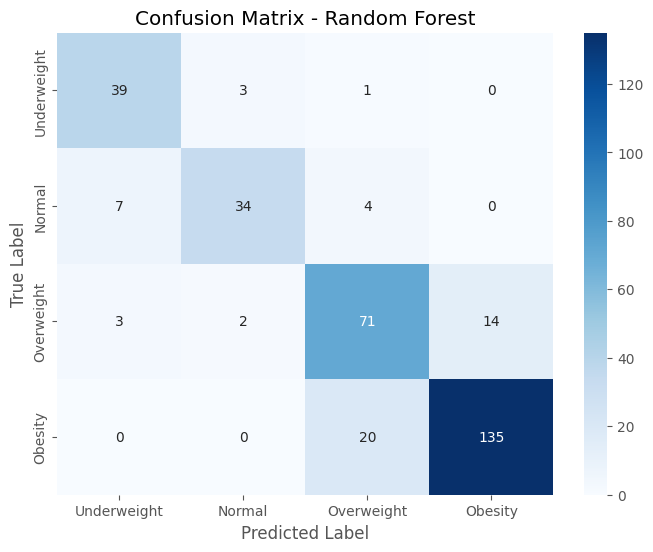

In [184]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Selection of the best model
best_model = models['Random Forest']
y_pred = best_model.predict(X_val)

# 2. Classification Report
label_names = ['Underweight', 'Normal', 'Overweight', 'Obesity']
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=label_names))

# 3. Confusion Matrix Visualization
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [185]:
df_train_scaled.describe()

,Age,BMI,Water_Intake_Per_Kg,FAF,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num,Weight_Status_Num
count,1.665e+03,1.665e+03,1.665e+03,1665.000,1665.000,1665.000,1665.000,1665.000,1665.000
mean,7.856e-04,-3.155e-04,1.393e-05,-1.133,0.828,1.139,0.885,0.044,2.076
std,9.359e-01,9.421e-01,9.423e-01,2.972,0.377,0.454,0.319,0.206,1.053
min,-5.199e+00,-5.199e+00,-5.199e+00,-5.000,0.000,0.000,0.000,0.000,0.000
25%,-9.575e-01,-8.883e-01,-8.846e-01,-5.000,1.000,1.000,1.000,0.000,1.000
50%,-5.020e-02,-1.255e-03,0.000e+00,0.000,1.000,1.000,1.000,0.000,2.000
75%,8.463e-01,8.846e-01,8.846e-01,1.000,1.000,1.000,1.000,0.000,3.000
max,5.199e+00,5.199e+00,5.199e+00,5.000,1.000,3.000,1.000,1.000,3.000


In [186]:
df_test_scaled.describe()

,Age,BMI,Water_Intake_Per_Kg,FAF,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num
count,418.000,418.000,418.000,418.000,418.000,418.000,418.000,418.000
mean,-0.036,-0.015,0.039,-1.478,0.813,1.172,0.876,0.053
std,1.036,1.018,1.059,3.054,0.390,0.479,0.330,0.224
min,-2.348,-2.470,-3.098,-5.199,0.000,0.000,0.000,0.000
25%,-0.537,-0.500,-0.497,-5.199,1.000,1.000,1.000,0.000
50%,0.425,-0.498,0.496,0.038,1.000,1.000,1.000,0.000
75%,0.427,0.497,0.500,0.909,1.000,1.000,1.000,0.000
max,2.501,2.497,5.199,5.199,1.000,3.000,1.000,1.000


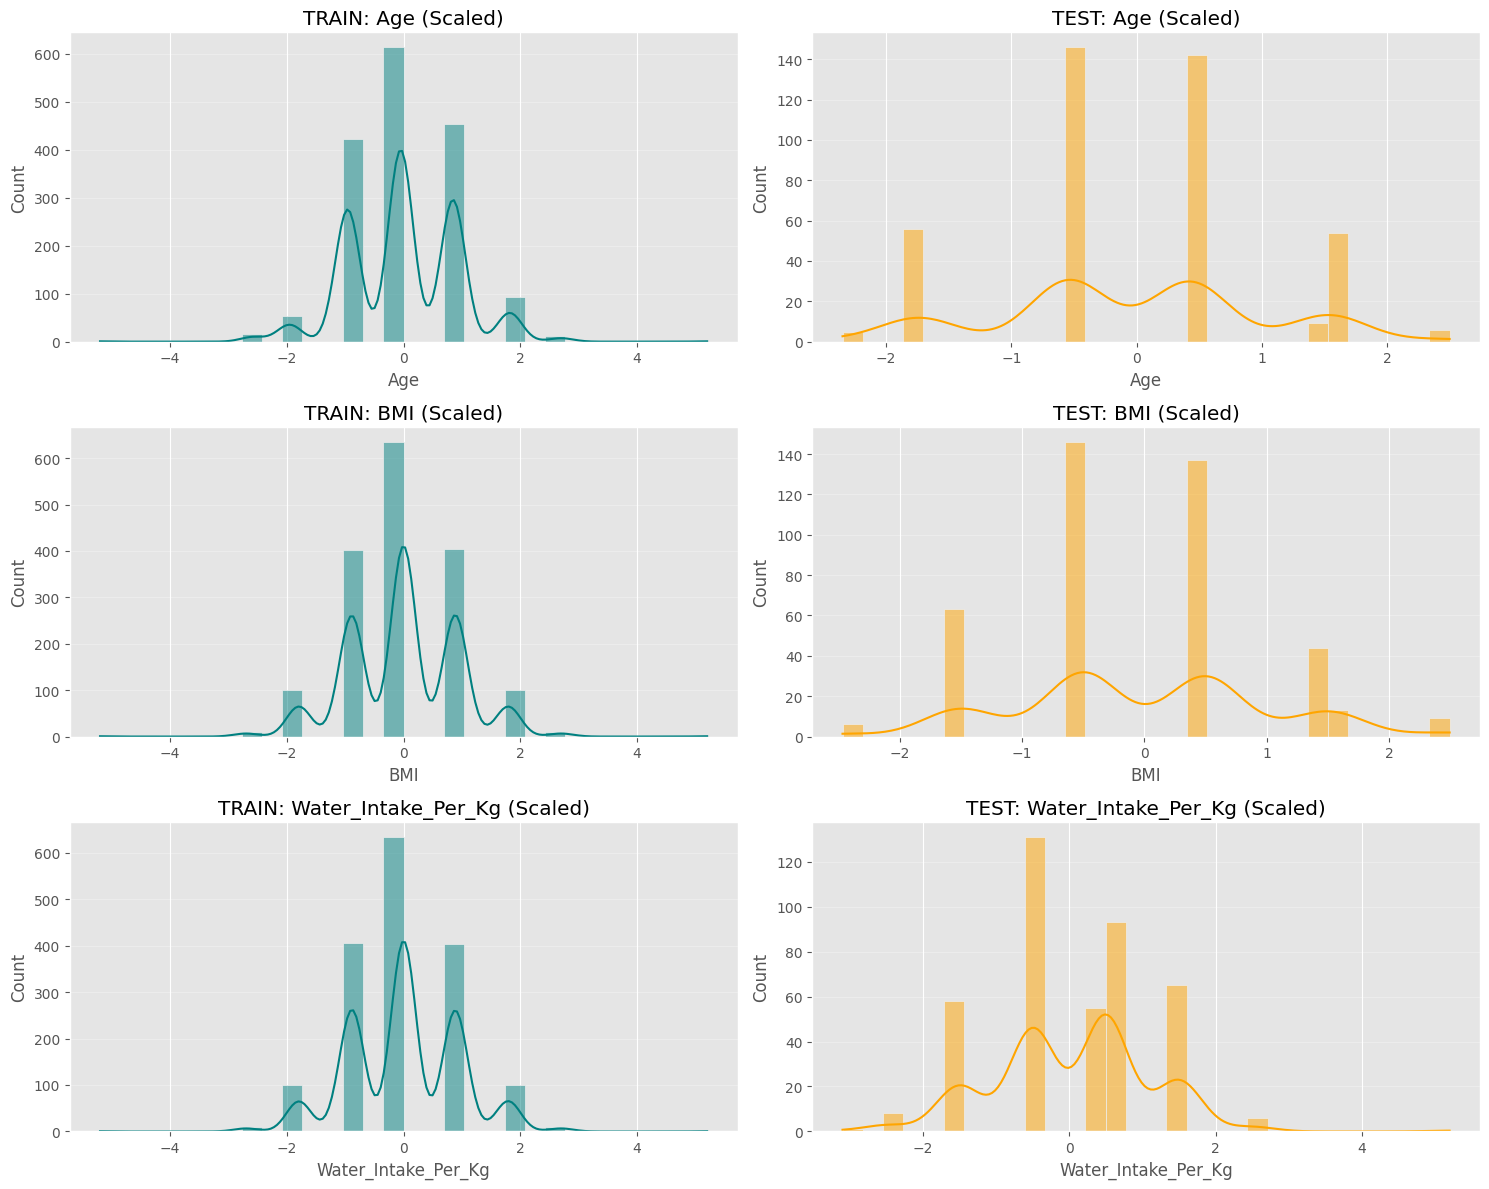

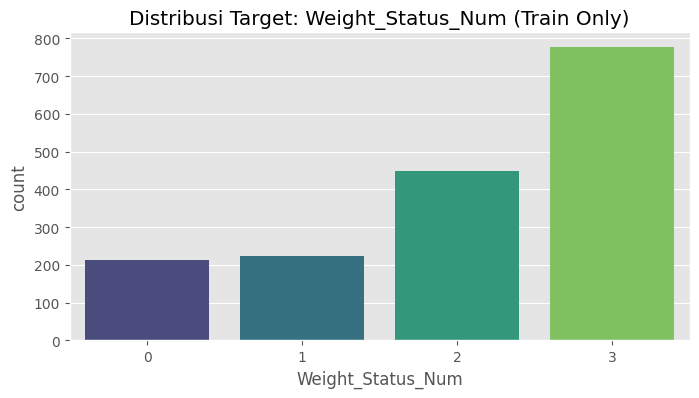

In [187]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tentukan list fitur yang di-scale
features_to_plot = ['Age', 'BMI', 'Water_Intake_Per_Kg']
target_col = 'Weight_Status_Num'

n_cols = 2  # Kolom kiri untuk Train, Kolom kanan untuk Test
n_rows = len(features_to_plot)

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(features_to_plot):
    # --- PLOT DATA TRAIN (KIRI) ---
    plt.subplot(n_rows, n_cols, 2*i + 1)
    sns.histplot(df_train_scaled[col], kde=True, color='teal', bins=30)
    plt.title(f'TRAIN: {col} (Scaled)')
    plt.grid(axis='y', alpha=0.3)

    # --- PLOT DATA TEST (KANAN) ---
    plt.subplot(n_rows, n_cols, 2*i + 2)
    sns.histplot(df_test_scaled[col], kde=True, color='orange', bins=30)
    plt.title(f'TEST: {col} (Scaled)')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Khusus Visualisasi Target (Hanya ada di Train)
plt.figure(figsize=(8, 4))
sns.countplot(x=df_train_scaled[target_col], palette='viridis')
plt.title(f'Distribusi Target: {target_col} (Train Only)')
plt.show()


*Save data hasil scaling dalam format csv*

In [188]:
# Simpan Data Train yang sudah di-scale
df_train_scaled.to_csv('df_train_scaled.csv', index=False)

# Simpan Data Test yang sudah di-scale
df_test_scaled.to_csv('df_test_scaled.csv', index=False)

print("✅ File CSV berhasil disimpan!")

✅ File CSV berhasil disimpan!


## Modeling

In [189]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# 1. Menyiapkan X & y dari hasil split (df_train_split)
X_train = df_train_split.drop(columns=['Weight_Status_Num'])
y_train = df_train_split['Weight_Status_Num']

X_val = df_test_split.drop(columns=['Weight_Status_Num'])
y_val = df_test_split['Weight_Status_Num']

print(f"Shape X_train : {X_train.shape}")
print(f"Shape X_val   : {X_val.shape}")
print(f"Fitur         : {X_train.columns.tolist()}")

# 2. Definisi kandidat model
models = {
    "Logistic Regression"    : LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree"          : DecisionTreeClassifier(random_state=42),
    "Random Forest"          : RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting"      : GradientBoostingClassifier(n_estimators=200, random_state=42),
    "K-Nearest Neighbors"    : KNeighborsClassifier(n_neighbors=7),
    "Support Vector Machine" : SVC(kernel='rbf', probability=True, random_state=42),
}

# 3. Training + Cross-Validation
results = []
trained_models = {}

print("\n" + "="*65)
print(f" {'Model':<28}  CV-Mean   Train-Acc")
print("="*65)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    trained_models[name] = model
    results.append({
        'Model': name,
        'CV_Mean': cv_scores.mean(),
        'Train_Accuracy': train_acc
    })
    print(f" {name:<28}  {cv_scores.mean():.4f}    {train_acc:.4f}")

results_df = pd.DataFrame(results).sort_values('CV_Mean', ascending=False)
print("="*65)

Shape X_train : (1332, 8)
Shape X_val   : (333, 8)
Fitur         : ['Age', 'BMI', 'Water_Intake_Per_Kg', 'FAF', 'family_history_with_overweight_Num', 'CAEC_Num', 'FAVC_Num', 'SCC_Num']

 Model                         CV-Mean   Train-Acc
 Logistic Regression           0.7395    0.7598
 Decision Tree                 0.8191    0.8964
 Random Forest                 0.8228    0.8964
 Gradient Boosting             0.8266    0.8821
 K-Nearest Neighbors           0.7921    0.8318
 Support Vector Machine        0.7597    0.7793


## Model Evaluation

🏆 Model Terbaik  : Gradient Boosting
   CV Accuracy    : 0.8266
   Val Accuracy   : 0.8258

📋 Classification Report (Validation Set):
              precision    recall  f1-score   support

 Underweight       0.81      0.81      0.81        43
      Normal       0.80      0.73      0.77        45
  Overweight       0.71      0.83      0.77        90
     Obesity       0.92      0.85      0.89       155

    accuracy                           0.83       333
   macro avg       0.81      0.81      0.81       333
weighted avg       0.83      0.83      0.83       333



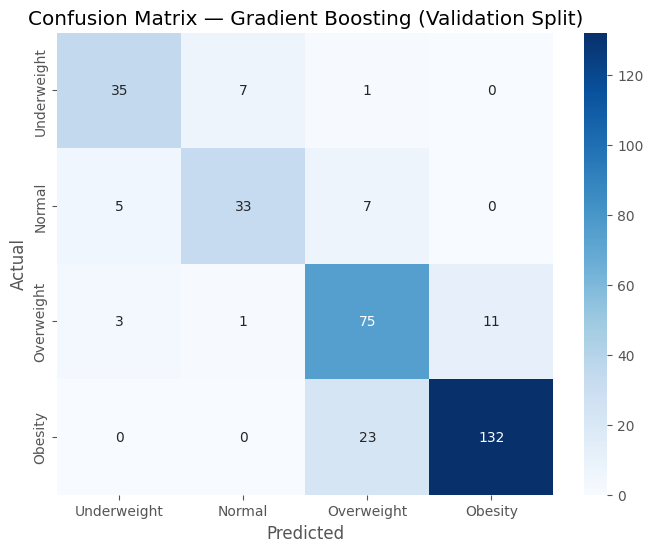


✅ Model 'Gradient Boosting' berhasil disimpan ke best_model_obesitas.pkl


In [190]:
# ── 4. Evaluasi Model Terbaik pada Data Validasi ──────────────────────────
best_name = results_df.iloc[0]['Model']
best_model = trained_models[best_name]

# Evaluasi pada data validasi (X_val)
y_pred_val = best_model.predict(X_val)
val_acc = accuracy_score(y_val, y_pred_val)

print(f"🏆 Model Terbaik  : {best_name}")
print(f"   CV Accuracy    : {results_df.iloc[0]['CV_Mean']:.4f}")
print(f"   Val Accuracy   : {val_acc:.4f}")

# Label mapping
label_map = {0: 'Underweight', 1: 'Normal', 2: 'Overweight', 3: 'Obesity'}

# Classification report
print("\n📋 Classification Report (Validation Set):")
print(classification_report(y_val, y_pred_val,
                             target_names=[label_map[i] for i in sorted(label_map)]))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label_map[i] for i in sorted(label_map)],
            yticklabels=[label_map[i] for i in sorted(label_map)])
plt.title(f'Confusion Matrix — {best_name} (Validation Split)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ── 5. Simpan Model & Scaler ──────────────────────────────────────────────
import joblib
joblib.dump(best_model, 'best_model_obesitas.pkl')
# Catatan: Scaler sudah disimpan sebelumnya di sel 721633f7
print(f"\n✅ Model '{best_name}' berhasil disimpan ke best_model_obesitas.pkl")